# E-commerce User Behavior Analysis

1. Business Context

Every day, thousands of users browse an online store — yet only a small
fraction of those visits end in a purchase. For an e-commerce business,
understanding the difference between a visitor who buys and one who leaves
is the key to growing revenue without increasing traffic spend.

This analysis takes on that challenge using a public dataset of **12,330
real user sessions** from an online retailer (UCI Machine Learning
Repository). Each session captures how the user navigated the site — pages
visited, time spent, bounce and exit rates — along with contextual
information such as the month, the visitor type and whether the session
took place near a special day.

The goal is to answer three business questions:

1. **Which browsing behaviors are most associated with completed purchases?**
2. **Do returning visitors convert better than new visitors?**
3. **Are there seasonal patterns the business should plan around?**

The findings, summarized at the end of this notebook, are translated into
concrete recommendations the marketing and product teams could act on.




2. Data Loading & First Look

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

In [40]:
print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [41]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [42]:
# Statistical summary of numerical variables
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [43]:
# Missing values and duplicated rows check
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())

Missing values per column:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Duplicated rows: 125


In [44]:
# Target variable: share of sessions ending in a purchase
df["Revenue"].value_counts(normalize=True)

,proportion
Revenue,
False,0.845255
True,0.154745


**First look — key observations:**
- 12,330 sessions and 18 variables, no missing values.
- 125 duplicated rows to be removed in the cleaning step.
- Only **15.5% of sessions end in a purchase** — understanding what
  distinguishes these sessions is the core of this analysis.
- Browsing-time variables are heavily right-skewed: a small group of
  users spends far more time on the site than the average visitor.

3. Data Cleaning & Preparation

In [45]:
# Remove duplicated rows (identical sessions add no information)
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {rows_before - len(df)} duplicated rows. New shape: {df.shape}")

Removed 125 duplicated rows. New shape: (12205, 18)


In [46]:
# Convert Month to an ordered categorical variable for correct chronological plots
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)
df["Month"].value_counts().sort_index()

,count
Month,
Feb,181
Mar,1860
May,3329
June,285
Jul,432
Aug,433
Sep,448
Oct,549
Nov,2982


In [47]:
# Create a readable label for the target variable
df["Purchase"] = df["Revenue"].map({True: "Purchase", False: "No purchase"})
df["Purchase"].value_counts()

,count
Purchase,
No purchase,10297
Purchase,1908


**Cleaning summary:** 125 duplicated sessions removed (12,205 remaining).
`Month` converted to an ordered categorical variable for chronological
analysis, and a readable `Purchase` label created from the target variable.
No missing values required treatment.

4. Exploratory Data Analysis

In [48]:
# Set a consistent visual style for all charts
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)

### 4.1 Which browsing behaviors are associated with purchases?

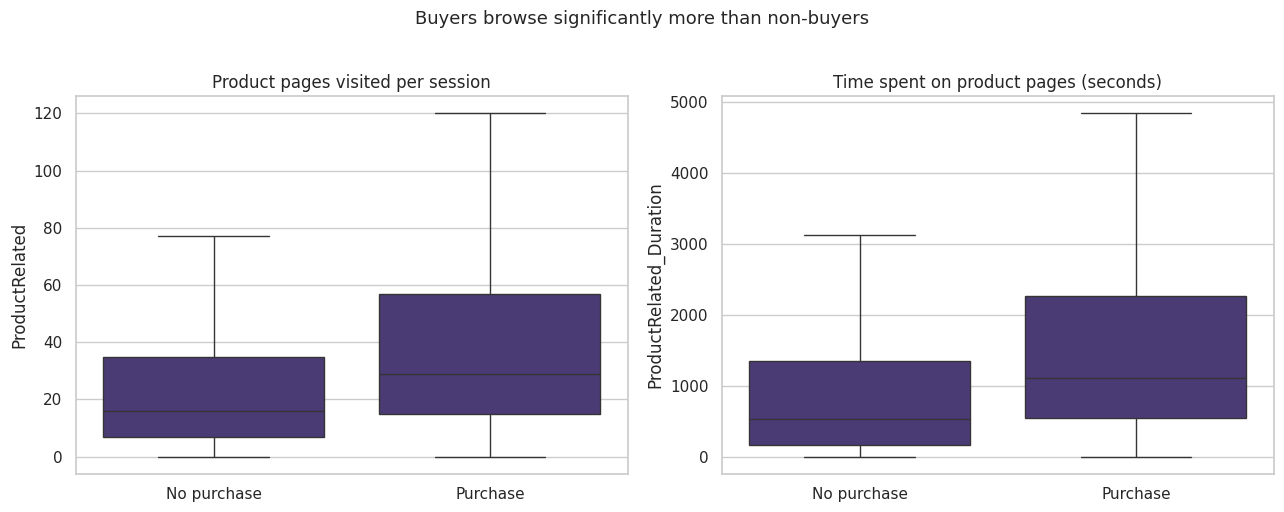

In [49]:
# Compare product browsing behavior: buyers vs non-buyers
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Purchase", y="ProductRelated", ax=axes[0], showfliers=False)
axes[0].set_title("Product pages visited per session")
axes[0].set_xlabel("")

sns.boxplot(data=df, x="Purchase", y="ProductRelated_Duration", ax=axes[1], showfliers=False)
axes[1].set_title("Time spent on product pages (seconds)")
axes[1].set_xlabel("")

plt.suptitle("Buyers browse significantly more than non-buyers", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

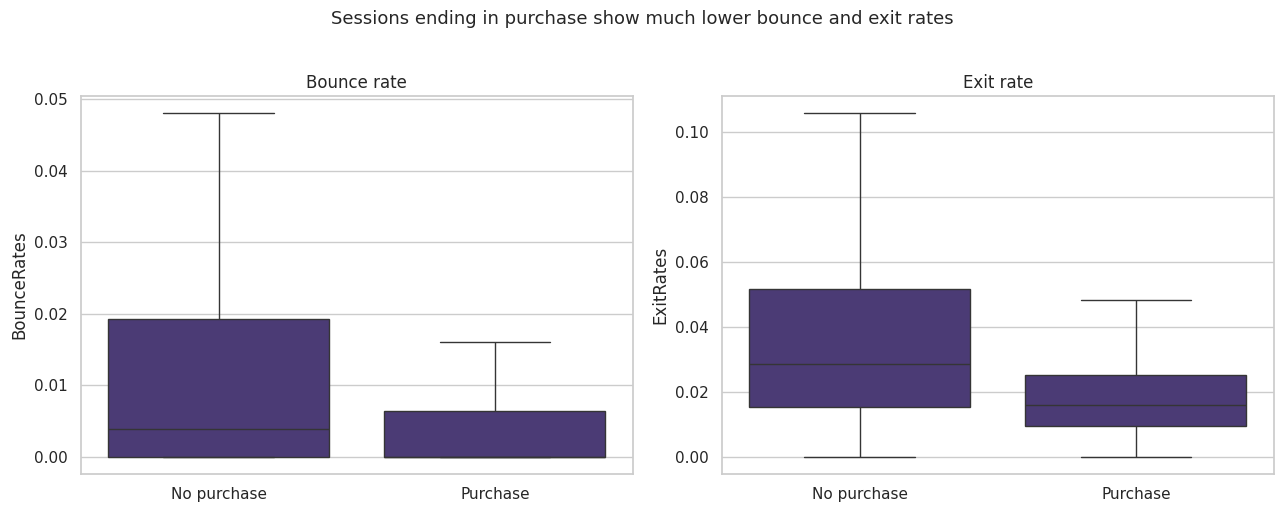

In [50]:
# Bounce and exit rates: buyers vs non-buyers
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Purchase", y="BounceRates", ax=axes[0], showfliers=False)
axes[0].set_title("Bounce rate")
axes[0].set_xlabel("")

sns.boxplot(data=df, x="Purchase", y="ExitRates", ax=axes[1], showfliers=False)
axes[1].set_title("Exit rate")
axes[1].set_xlabel("")

plt.suptitle("Sessions ending in purchase show much lower bounce and exit rates", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

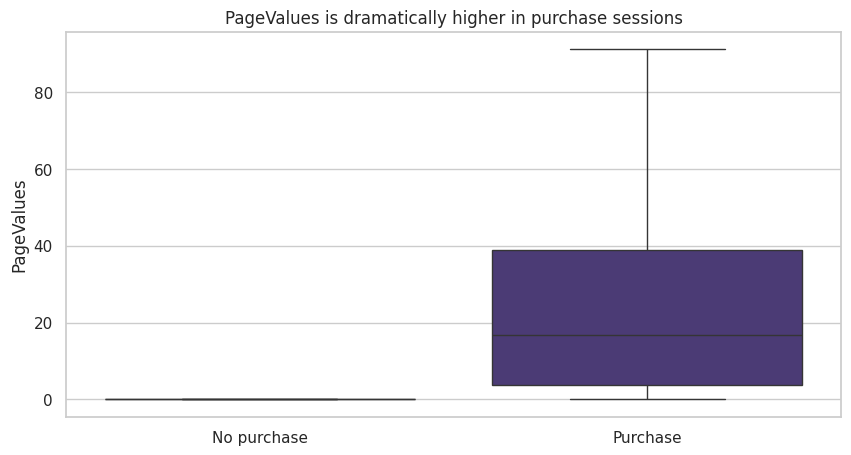

In [51]:
# PageValues: the strongest signal of purchase intent
sns.boxplot(data=df, x="Purchase", y="PageValues", showfliers=False)
plt.title("PageValues is dramatically higher in purchase sessions")
plt.xlabel("")
plt.show()

**Observations:** Purchase sessions involve far more product pages and
browsing time, with drastically lower bounce/exit rates. `PageValues`
(Google Analytics' measure of a page's contribution to revenue) is near
zero for non-buyers and clearly positive for buyers — the single
strongest behavioral signal in the dataset.

### 4.2 Do returning visitors convert better?

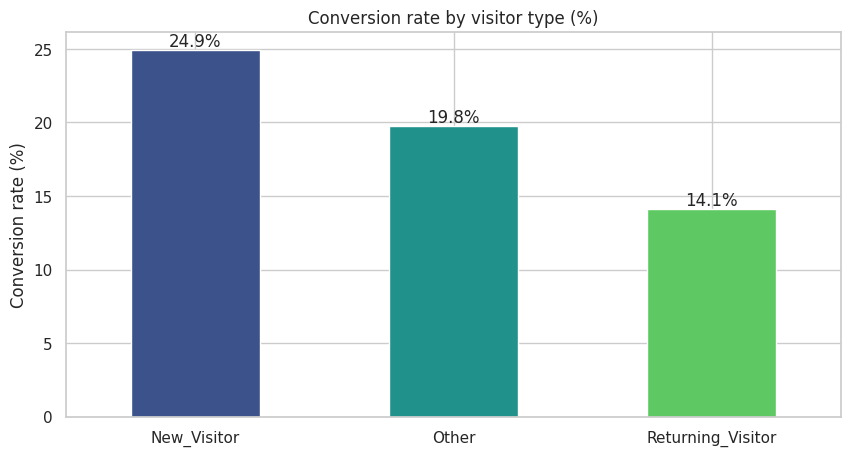

In [52]:
# Conversion rate by visitor type
conv_visitor = df.groupby("VisitorType")["Revenue"].mean().sort_values(ascending=False) * 100

ax = conv_visitor.plot(kind="bar", color=sns.color_palette("viridis", 3))
ax.set_title("Conversion rate by visitor type (%)")
ax.set_ylabel("Conversion rate (%)")
ax.set_xlabel("")
ax.bar_label(ax.containers[0], fmt="%.1f%%")
plt.xticks(rotation=0)
plt.show()

**Observations:** Counterintuitively, *new* visitors convert at a higher
rate than returning ones. Returning visitors generate more sessions
overall, but many of those visits appear to be research or comparison
visits rather than buying visits — an opportunity for re-engagement
campaigns targeting returning users.

### 4.3 Are there seasonal patterns?

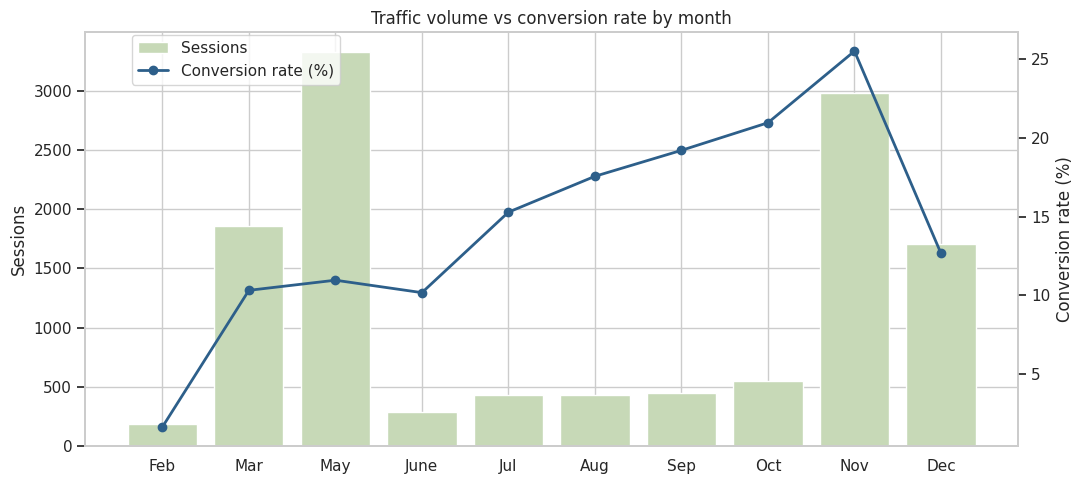

In [53]:
# Sessions and conversion rate by month
monthly = df.groupby("Month", observed=True).agg(
    sessions=("Revenue", "size"),
    conversion_rate=("Revenue", "mean")
)
monthly["conversion_rate"] *= 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(monthly.index.astype(str), monthly["sessions"], color="#c7d9b7", label="Sessions")
ax1.set_ylabel("Sessions")

ax2 = ax1.twinx()
ax2.plot(monthly.index.astype(str), monthly["conversion_rate"], color="#2d5f8a",
         marker="o", linewidth=2, label="Conversion rate (%)")
ax2.set_ylabel("Conversion rate (%)")
ax2.grid(False)

plt.title("Traffic volume vs conversion rate by month")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.93))
plt.tight_layout()
plt.show()

**Observations:** November stands out with both peak traffic and the
highest conversion rate — consistent with Black Friday and pre-holiday
shopping. May attracts high traffic but converts poorly, suggesting
browsing-oriented visits. February is the weakest month on both metrics.

5. Key Findings & Business Recommendations

### Key Findings

**1. Buying behavior is visible in navigation patterns.** Purchase
sessions involve substantially more product pages, longer browsing time,
and much lower bounce/exit rates. `PageValues` is the strongest single
signal: near zero for non-buyers, clearly positive for buyers.

**2. New visitors convert better than returning ones (25% vs 14%).**
Returning visitors generate most of the traffic, but a large share of
their sessions are research visits that do not end in purchase.

**3. Seasonality is strong and asymmetric.** November combines peak
traffic with the highest conversion rate of the year (Black Friday /
pre-holiday effect). May brings high traffic but low conversion, and
February is the weakest month on both metrics.

### Business Recommendations

**• Use engagement signals for real-time targeting.** Sessions with high
product-page depth and low bounce behave like buyers. Trigger assistance
(chat, limited-time offers, free-shipping reminders)